In [ ]:
import os
import zipfile

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
root_folder_path = '/content/'
dataset_zip_path = f'{root_folder_path}drive/MyDrive/MultimodalGasData.zip'

In [ ]:
DeIT_Fine_Tuned_Model_Path = '/content/drive/MyDrive/DeIT_Fine_Tuned_Model.pth'
lstm_model_path = '/content/drive/MyDrive/best_lstm_model.keras'

In [ ]:
if not os.path.exists(f'{root_folder_path}Gas Sensors Measurements'):
  with zipfile.ZipFile(dataset_zip_path, 'r') as zip_ref:
    zip_ref.extractall(root_folder_path)

In [ ]:
import random, numpy as np, tensorflow as tf
from tensorflow.keras import backend as K

os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
K.clear_session()

In [ ]:
import pandas as pd

In [ ]:
dataset_root_path = '/content/'
sensor_dataset_path = os.path.join(dataset_root_path, 'Gas Sensors Measurements/Gas_Sensors_Measurements.csv')
thermal_dataset_path = os.path.join(dataset_root_path, 'Thermal Camera Images/')

In [ ]:
df = pd.read_csv(sensor_dataset_path)

In [ ]:
df.head()

,Serial Number,MQ2,MQ3,MQ5,MQ6,MQ7,MQ8,MQ135,Gas,Corresponding Image Name
0,0,555,515,377,338,666,451,416,NoGas,0_NoGas
1,1,555,516,377,339,666,451,416,NoGas,1_NoGas
2,2,556,517,376,337,666,451,416,NoGas,2_NoGas
3,3,556,516,376,336,665,451,416,NoGas,3_NoGas
4,4,556,516,376,337,665,451,416,NoGas,4_NoGas


In [ ]:
df_duplicate = df.copy()

In [ ]:
df.drop('Serial Number', axis=1, inplace=True)

# Data Preprocessing

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
df.drop('Corresponding Image Name', axis=1, inplace=True)

In [ ]:
le = LabelEncoder()
df['Gas'] = le.fit_transform(df['Gas'])

In [ ]:
for i, class_name in enumerate(le.classes_):
    print(f"{i}: {class_name}")

0: Mixture
1: NoGas
2: Perfume
3: Smoke


In [ ]:
X = df.drop('Gas', axis=1)
y = df['Gas']

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

In [ ]:
scaler.fit(X)
X = scaler.transform(X)

In [ ]:
import numpy as np

n_classes = 4
samples_per_class = 1600

train_ratio = 0.8
test_ratio = 0.2

X_train, y_train = [], []
X_test, y_test = [], []

for cls in range(n_classes):
    start = cls * samples_per_class
    end = start + samples_per_class

    X_cls = X[start:end]
    y_cls = y[start:end]

    n_train = int(train_ratio * samples_per_class)

    X_train.append(X_cls[:n_train])
    y_train.append(y_cls[:n_train])

    X_test.append(X_cls[n_train:])
    y_test.append(y_cls[n_train:])

X_train = np.concatenate(X_train)
y_train = np.concatenate(y_train)
X_test = np.concatenate(X_test)
y_test = np.concatenate(y_test)

In [ ]:
print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Test:  {X_test.shape}, {y_test.shape}")

Train: (5120, 7), (5120,)
Test:  (1280, 7), (1280,)


In [ ]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

n_input = 7
n_features = 7
batch_size = 64

train_gen = TimeseriesGenerator(X_train, y_train, length=n_input, batch_size=batch_size)
test_gen = TimeseriesGenerator(X_test, y_test, length=n_input, batch_size=batch_size)

In [ ]:
len(train_gen) * train_gen.batch_size

5120

In [ ]:
len(test_gen) * test_gen.batch_size

1280

# Loading Fine-Tuned DeIT Model

In [ ]:
from keras.models import load_model

In [ ]:
import numpy as nump
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
import torch.optim as optim
import pickle
import timm
import torch.nn as nn
from tqdm import tqdm

file = thermal_dataset_path

In [ ]:
from torch.utils.data import DataLoader, Subset
import numpy as np

transformed_training = transforms.Compose([transforms.Resize((224, 224)),
                                           transforms.ToTensor(),
                                           transforms.Normalize(mean = [0.5, 0.5, 0.5],
                                                                std = [0.5, 0.5, 0.5])])
dataset = datasets.ImageFolder(file, transform = transformed_training)

dataset_size = len(dataset)
print(f'Dataset Size: {dataset_size}')
indices = np.arange(dataset_size)

n_classes = 4
samples_per_class = 1600
train_ratio = 0.8
test_ratio = 0.2

train_indices = []
test_indices = []

for cls in range(n_classes):
    start = cls * samples_per_class
    end = start + samples_per_class

    cls_indices = indices[start:end]

    n_train = int(train_ratio * samples_per_class)

    train_indices.extend(cls_indices[:n_train])
    test_indices.extend(cls_indices[n_train:])

training_transformed = Subset(dataset, train_indices)
testing_transformed = Subset(dataset, test_indices)

testing_dataloader = DataLoader(testing_transformed, batch_size=32, shuffle=False)
training_dataloader = DataLoader(training_transformed, batch_size=32, shuffle=False)


print(f'Train Size: {len(train_indices)}')
print(f'Test Size: {len(test_indices)}')

Dataset Size: 6400
Train Size: 5120
Test Size: 1280


In [ ]:
loaded_state_dict = torch.load(DeIT_Fine_Tuned_Model_Path, map_location=torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

deit_model = timm.create_model('deit_base_patch16_224', pretrained=False, num_classes=4)

deit_model.load_state_dict(loaded_state_dict)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

deit_model.to(device)

deit_model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
print(f'Evaluating Loaded DeIT Model')

real_prediction = 0
complete_test_data = 0
complete_class_test_data = [0] * 4
real_class_prediction = [0] * 4
class_names = ['No Gas', 'Perfume', 'Smoke', 'Mixture']
with torch.no_grad():
  for batch_images, batch_labels in tqdm(testing_dataloader, desc = 'Evaluating'):
    batch_images = batch_images.to(device)
    batch_labels = batch_labels.to(device)
    outputs = deit_model(batch_images)
    _, batch_predictions = outputs.max(1)
    complete_test_data = complete_test_data + batch_labels.size(0)
    real_prediction = real_prediction + (batch_predictions == batch_labels).sum().item()
    for batch_label, batch_prediction in zip(batch_labels, batch_predictions):
      complete_class_test_data[batch_label] = complete_class_test_data[batch_label] + 1
      real_class_prediction[batch_label] = real_class_prediction[batch_label] + (batch_prediction == batch_label).sum().item()
print(f'The Testing Data Accuracy Is: {real_prediction / complete_test_data}')
for class_name, class_real_prediction, class_complete_test_data in zip(class_names, real_class_prediction, complete_class_test_data):
  print(f'The Testing Data Accuracy For The Class {class_name} Is: {class_real_prediction / class_complete_test_data}')

Evaluating Loaded DeIT Model


Evaluating: 100%|██████████| 40/40 [00:34<00:00,  1.14it/s]

The Testing Data Accuracy Is: 0.99765625
The Testing Data Accuracy For The Class No Gas Is: 1.0
The Testing Data Accuracy For The Class Perfume Is: 0.990625
The Testing Data Accuracy For The Class Smoke Is: 1.0
The Testing Data Accuracy For The Class Mixture Is: 1.0


# Loading Fine-Tuned LSTM

In [ ]:
from keras.models import load_model

In [ ]:
from keras.models import load_model

lstm_model = load_model(lstm_model_path)

In [ ]:
lstm_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 128)            │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,148 (274.02 KB)

 Trainable params: 70,148 (274.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_model.evaluate(test_gen)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9200 - loss: 0.2779


[0.22259943187236786, 0.9324430227279663]

# Early-Fusion using both loaded DeIT and LSTM

In [ ]:
from keras.models import Model
from keras.layers import Input

In [ ]:
lstm_feature_extractor = Model(inputs=lstm_model.get_layer(index=0).input,
                          outputs=lstm_model.layers[0].output)

lstm_features = lstm_feature_extractor.predict(train_gen)

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
deit_features = []

with torch.no_grad():
  for batch_images, _ in tqdm(training_dataloader, desc = f'Loading Training Data Features'):
    batch_images = batch_images.to(device)
    features = deit_model(batch_images)
    deit_features.append(features.cpu().numpy())

deit_features = np.vstack(deit_features)

Loading Training Data Features: 100%|██████████| 160/160 [02:20<00:00,  1.14it/s]


In [ ]:
lstm_features.shape

(5113, 128)

In [ ]:
deit_features.shape

(5120, 4)

In [ ]:
deit_features = deit_features[n_input:]

In [ ]:
deit_features.shape[0] == lstm_features.shape[0]

True

In [ ]:
from keras.layers import Dense, Dropout, Concatenate
from keras.optimizers import Adam

lstm_input = Input(shape=(lstm_features.shape[1],), name="lstm_input")
deit_input = Input(shape=(deit_features.shape[1],), name="deit_input")

x = Concatenate()([lstm_input, deit_input])
x = Dense(128, activation="gelu")(x)
x = Dropout(0.2)(x)
output = Dense(4, activation="softmax")(x)

fusion_model = Model(inputs=[lstm_input, deit_input], outputs=output)
fusion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
fusion_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ lstm_input          │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ deit_input          │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 132)       │          0 │ lstm_input[0][0], │
│ (Concatenate)       │                   │            │ deit_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     17,024 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        516 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 17,540 (68.52 KB)

 Trainable params: 17,540 (68.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

y_train_aligned = y_train[n_input:]

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True,
    mode='max',
    min_delta=1e-4
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

history = fusion_model.fit(
    [lstm_features, deit_features],
    y_train_aligned,
    batch_size=64,
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8304 - loss: 0.4498 - val_accuracy: 1.0000 - val_loss: 0.0084 - learning_rate: 0.0010
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9977 - loss: 0.0109 - val_accuracy: 1.0000 - val_loss: 0.0034 - learning_rate: 0.0010
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9994 - loss: 0.0058 - val_accuracy: 1.0000 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9992 - loss: 0.0040 - val_accuracy: 1.0000 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9992 - loss: 0.0035 - val_accuracy: 1.0000 - val_loss: 9.9025e-04 - learning_rate: 5.0000e-04
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 8.3564e-04 - learning_rate: 5.0000e-04
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9992 - loss: 0.0024 

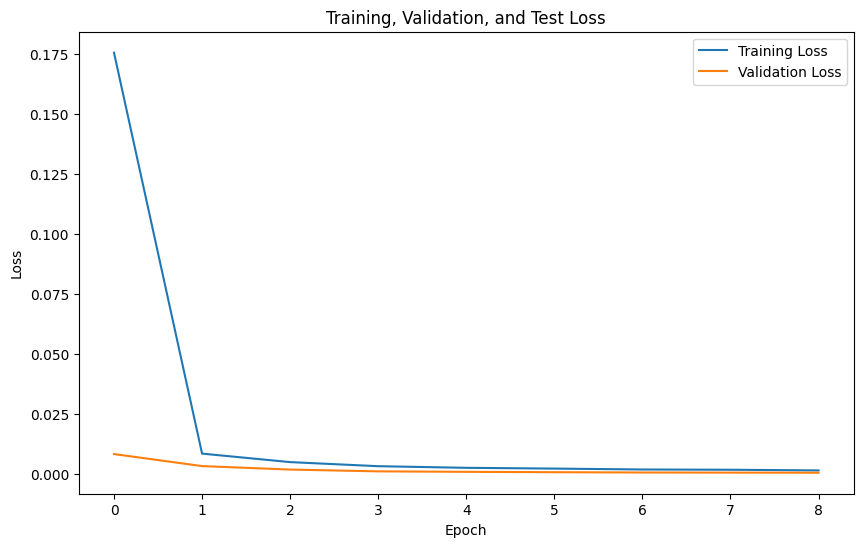

In [ ]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training, Validation, and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

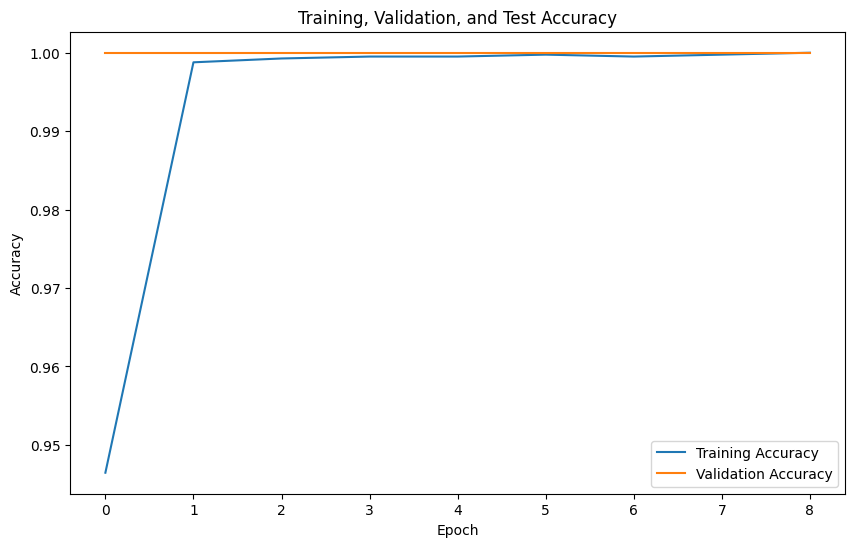

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training, Validation, and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Evaluation of Fusion Model

In [ ]:
lstm_test_features = lstm_feature_extractor.predict(test_gen)

deit_test_features = []
with torch.no_grad():
  for batch_images, _ in tqdm(testing_dataloader, desc = f'Loading Test Features'):
    batch_images = batch_images.to(device)
    features = deit_model(batch_images)
    deit_test_features.append(features.cpu().numpy())

deit_test_features = np.vstack(deit_test_features)

deit_test_features_aligned = deit_test_features[n_input:]

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


Loading Test Features: 100%|██████████| 40/40 [00:34<00:00,  1.17it/s]


In [ ]:
lstm_test_features.shape, deit_test_features_aligned.shape

((1273, 128), (1273, 4))

In [ ]:
y_test.size

1280

In [ ]:
y_test_aligned = y_test[n_input:]

loss, accuracy = fusion_model.evaluate([lstm_test_features, deit_test_features_aligned], y_test_aligned)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0164


In [ ]:
print("Fusion Model Test Accuracy: %.2f" % accuracy)
print("Fusion Model Test Loss: %.2f" % loss)

Fusion Model Test Accuracy: 1.00
Fusion Model Test Loss: 0.02


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_pred_multi = fusion_model.predict([lstm_test_features, deit_test_features_aligned])
y_pred = np.argmax(y_pred_multi, axis=1)

accuracy = np.mean(y_pred == y_test_aligned)
print(f"Exact Test Accuracy: {accuracy:.4f}")

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Exact Test Accuracy: 1.0000


In [ ]:
print('Confusion Matrix')
print(confusion_matrix(y_test_aligned, y_pred))

Confusion Matrix
[[320   0   0   0]
 [  0 313   0   0]
 [  0   0 320   0]
 [  0   0   0 320]]


In [ ]:
print(classification_report(y_test_aligned, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       320
           1       1.00      1.00      1.00       313
           2       1.00      1.00      1.00       320
           3       1.00      1.00      1.00       320

    accuracy                           1.00      1273
   macro avg       1.00      1.00      1.00      1273
weighted avg       1.00      1.00      1.00      1273



In [ ]:
fusion_model.save('Early-Fusion_DeIT_and_LSTM.keras')

In [ ]:
from keras.models import load_model

In [ ]:
model = load_model('Early-Fusion_DeIT_and_LSTM.keras')

In [ ]:
loss, acc = model.evaluate([lstm_features, deit_features], y_train_aligned)

160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9995 - loss: 0.0106


In [ ]:
print(f"Train Accuracy: {acc}")
print(f"Train Loss: {loss}")

Train Accuracy: 0.9990221261978149
Train Loss: 0.009914148598909378


In [ ]:
loss, acc = model.evaluate([lstm_test_features, deit_test_features_aligned], y_test_aligned)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0164


In [ ]:
print(f"Test Accuracy: {acc}")
print(f"Test Loss: {loss}")

Test Accuracy: 1.0
Test Loss: 0.023446613922715187
